In [46]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [47]:
df = pd.read_csv("combined_dataset.csv", encoding='latin-1')
df.columns = ['label', 'message']

In [67]:
df.head()

,label,message
0,1,Congratulations! You've been selected for a lu...
1,1,URGENT: Your account has been compromised. Cli...
2,1,You've won a free iPhone! Claim your prize by ...
3,1,Act now and receive a 50% discount on all purc...
4,1,Important notice: Your subscription will expir...


In [48]:

df['label'] = df['label'].astype(str).str.strip().str.lower()
df = df[df['label'].isin(['ham', 'spam'])].copy()
df['label'] = df['label'].map({'ham': 0, 'spam': 1}).astype(int)
print(df['label'].isna().sum())  

0


In [49]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

In [50]:
vectorizer = TfidfVectorizer(max_features=3000)
X = vectorizer.fit_transform(df['message']).toarray()
y = df['label']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [52]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [53]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [54]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9562243502051984


In [55]:
def predict_spam(text):
    text = clean_text(text)
    vector = vectorizer.transform([text]).toarray()
    result = model.predict(vector)
    return "Spam" if result[0] == 1 else "Not Spam"

print(predict_spam("Congratulations! You won a lottery"))

Not Spam


In [56]:
import matplotlib.pyplot as plt
%matplotlib inline


In [57]:
def plot_message_length(df):
    df['length'] = df['message'].apply(len)

    plt.hist(df[df['label'] == 0]['length'], bins=50, alpha=0.5, label='Ham')
    plt.hist(df[df['label'] == 1]['length'], bins=50, alpha=0.5, label='Spam')

    plt.legend()
    plt.title("Message Length Distribution")
    plt.xlabel("Length")
    plt.ylabel("Frequency")
    plt.show()

In [58]:
from collections import Counter

def plot_common_words(df):
    all_words = ' '.join(df['message']).split()
    common_words = Counter(all_words).most_common(20)

    words = [w[0] for w in common_words]
    counts = [w[1] for w in common_words]

    plt.bar(words, counts)
    plt.xticks(rotation=90)
    plt.title("Top 20 Common Words")
    plt.show()

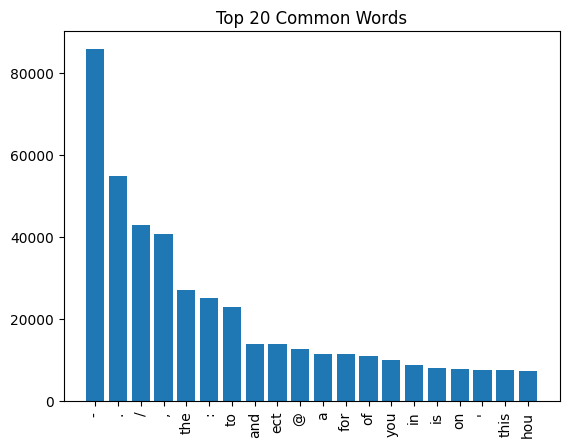

In [59]:
plot_common_words(df)

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

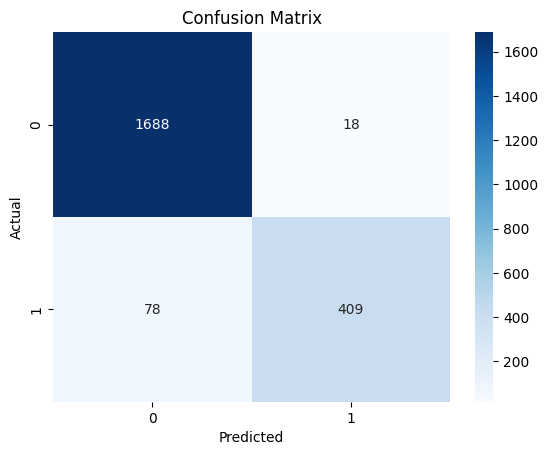

In [63]:
plot_confusion_matrix(y_test, y_pred)

In [64]:
from sklearn.metrics import classification_report
import pandas as pd

def plot_classification_report(y_test, y_pred):
    report = classification_report(y_test, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()

    sns.heatmap(df_report.iloc[:-1, :-1], annot=True, cmap="coolwarm")
    plt.title("Classification Report Heatmap")
    plt.show()

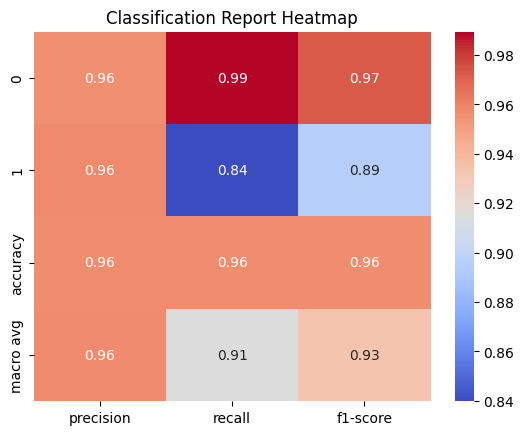

In [65]:
plot_classification_report(y_test, y_pred)